# Four-mode curvature model comparison

This notebook trains one model for each prediction mode:

1. `gaussian_only`
2. `mean_only`
3. `both_diagonal`
4. `both_full`

It then compares, separately for Gaussian and mean curvature, whether predicting that curvature alone performs better or worse than predicting both curvatures with diagonal or full covariance.

Run this notebook after updating your source files for multi-target support.

In [1]:
import copy
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"
sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128


## User switches

Edit these as needed. The four model modes are trained automatically.

In [2]:
DATASET_NAME = "mean_curvature_smooth"
data_dir = DATA_ROOT / DATASET_NAME

MODEL_CLASS_NAME = "GINCurvature"  # "GINCurvature" or "JKGINCurvature"

NUM_LAYERS = 4
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

TRAIN_CONFIG_KWARGS = dict(
    lr=3e-4,
    batch_size=128,
    max_epochs=2000,
    patience=30,
    num_workers=4,
)

USE_EDGE_LOSS = True
EDGE_LOSS_WEIGHT = 0.20

# Forced validation examples to inspect in mesh plots.
forced_keys = {
    ("20251201", "day4p5_B03_144"),
}

VAL_FRAC = 0.1
SPLIT_SEED = None

TARGET_LABELS_ALL = {
    0: "Gaussian curvature",
    1: "Mean curvature",
}

MODE_CONFIGS = {
    "gaussian_only": {"target_indices": [0], "covariance_mode": "diagonal"},
    "mean_only": {"target_indices": [1], "covariance_mode": "diagonal"},
    "both_diagonal": {"target_indices": [0, 1], "covariance_mode": "diagonal"},
    "both_full": {"target_indices": [0, 1], "covariance_mode": "full"},
}

COMPARISON_BY_CURVATURE = {
    0: ["baseline", "gaussian_only", "both_diagonal", "both_full"],
    1: ["baseline", "mean_only", "both_diagonal", "both_full"],
}

MODE_DISPLAY_NAMES = {
    "baseline": "baseline",
    "gaussian_only": "curvature only",
    "mean_only": "curvature only",
    "both_diagonal": "both, diagonal",
    "both_full": "both, covariant",
}

## Helper functions

In [3]:
def as_2d_targets(a):
    a = np.asarray(a)
    if a.ndim == 1:
        return a[:, None]
    if a.ndim == 2:
        return a
    raise ValueError(f"Expected 1D or 2D target array, got shape {a.shape}")


def select_target_array(a, target_index):
    a2 = as_2d_targets(a)
    if target_index >= a2.shape[1]:
        raise IndexError(f"target_index={target_index}, array shape={a2.shape}")
    return a2[:, int(target_index)]


def prepare_scalar_prediction_arrays(y, mu, log_var=None, target_index=0):
    y_s = select_target_array(y, target_index)
    mu_s = select_target_array(mu, target_index)
    if log_var is None:
        lv_s = None
    else:
        lv_s = select_target_array(log_var, target_index)
    return y_s, mu_s, lv_s


def finite_mse(y, yp):
    y = np.asarray(y, dtype=float)
    yp = np.asarray(yp, dtype=float)
    good = np.isfinite(y) & np.isfinite(yp)
    return float(np.mean((yp[good] - y[good]) ** 2)) if np.any(good) else np.nan


def finite_mae(y, yp):
    y = np.asarray(y, dtype=float)
    yp = np.asarray(yp, dtype=float)
    good = np.isfinite(y) & np.isfinite(yp)
    return float(np.mean(np.abs(yp[good] - y[good]))) if np.any(good) else np.nan


def safe_sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size <= 1:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(x.size))


def clone_graphs(graphs):
    return [copy.deepcopy(g) for g in graphs]


def select_graph_targets(graphs, target_indices, *, inplace=False):
    import copy
    import torch

    graphs_out = graphs if inplace else [copy.deepcopy(g) for g in graphs]
    target_indices = list(target_indices)

    for g in graphs_out:
        y = g.y

        if y.ndim == 1:
            if target_indices != [0]:
                raise ValueError(
                    "This graph has 1D targets, so only target index 0 exists. "
                    "You are probably reusing graphs that were already target-selected. "
                    "Use a pristine/deep-copied copy of the original two-target graphs."
                )
            g.y = y.contiguous()

        elif y.ndim == 2:
            idx = torch.as_tensor(target_indices, dtype=torch.long, device=y.device)
            g.y = y.index_select(dim=1, index=idx).contiguous()
            if g.y.shape[1] == 1:
                g.y = g.y[:, 0].contiguous()

        else:
            raise ValueError(f"Expected g.y to be 1D or 2D, got shape {tuple(y.shape)}")

    return graphs_out


def target_index_within_mode(mode_name, original_target_index):
    target_indices = MODE_CONFIGS[mode_name]["target_indices"]
    if original_target_index not in target_indices:
        return None
    return target_indices.index(original_target_index)


def make_model_for_mode(mode_name, n_markers, global_dim):
    from src.models.gnn import GINCurvature, JKGINCurvature
    model_cls = {"GINCurvature": GINCurvature, "JKGINCurvature": JKGINCurvature}[MODEL_CLASS_NAME]
    cfg = MODE_CONFIGS[mode_name]
    return model_cls(
        n_markers=n_markers,
        global_dim=global_dim,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
        target_dim=len(cfg["target_indices"]),
        covariance_mode=cfg["covariance_mode"],
    )


def extract_node_array_for_selected_graphs(source_graphs, selected_graphs, values, *, key_attr="organoid_str"):
    value_map = {}
    offset = 0
    for g in source_graphs:
        n = int(g.y.shape[0])
        key = getattr(g, key_attr)
        value_map[key] = np.asarray(values[offset:offset + n])
        offset += n

    out = []
    for g in selected_graphs:
        key = getattr(g, key_attr)
        out.append(value_map[key])
    return np.concatenate(out, axis=0)

## Load and preprocess graphs

This mirrors your existing single-model notebook. Modify this section if your preprocessing differs.

In [4]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import (
    load_aux_metadata_for_dir,
    attach_metadata_to_graphs,
    print_graph_and_metadata_fields,
    fill_missing_metadata_for_group,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    add_log_metadata_features,
    promote_metadata_to_graph_tensors,
    infer_global_dim,
    load_marker_names_from_dir,
)

# Load all organoids with all target columns. Target selection happens per mode later.
graphs_all = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs_all)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attach_metadata_to_graphs(graphs_all, meta)

print_graph_and_metadata_fields(graphs_all)


Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [5]:

# Optional dataset-specific fixes/filters from your previous notebook.
graphs_all = fill_missing_metadata_for_group(
    graphs_all,
    field="complexity",
    fill_value=2.1,
    dataset="20251201",
    timepoint="day4p5",
)

graphs_all = filter_graphs_by_numeric_metadata(
    graphs_all,
    key="complexity",
    min_value=2.0,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)


filter_graphs_by_numeric_metadata(key='complexity', min_value=2.0, max_value=None): kept 793 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                195    342    0.570
20250929         day4p5               75    104    0.721
20250929         day4p5-more         246    411    0.599
20251201         day4p5              277    277    1.000


In [6]:

graphs_all = filter_graphs_by_sphericity(
    graphs_all,
    max_sphericity=0.915,
    print_summary=True,
)


filter_graphs_by_sphericity(max_sphericity=0.915): kept 699 / 793 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                193    195    0.990
20250929         day4p5               74     75    0.987
20250929         day4p5-more         240    246    0.976
20251201         day4p5              192    277    0.693


In [7]:
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

graphs_all, outlier_info = interpolate_target_outliers_from_neighbors(
    graphs_all,
    clip_quantiles=(0.005, 0.995),
)

=== Target outlier interpolation report ===
Quantiles: (0.005, 0.995)
target 0: range=[-0.382588, 0.325509] | outliers=3416 | replaced=3416 | fallback=910
target 1: range=[-0.222456, 0.514917] | outliers=3416 | replaced=3416 | fallback=642


In [8]:

graphs_all = add_log_metadata_features(graphs_all, inplace=False)

graphs_all = promote_metadata_to_graph_tensors(
    graphs_all,
    field_specs=[
        {
            "meta_keys": [
                "log_surface_area",
                "log_volume",
                "log_volume_over_area",
                "log_num_cells",
            ],
            "attr_name": "global_feat",
            "kind": "graph_vector",
            "dtype": torch.float32,
        },
    ],
    inplace=False,
)

marker_names = load_marker_names_from_dir(data_dir)
print("marker_names:", marker_names)

marker_names: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']


## Split once, then clone per mode

All four models use the same train/validation organoids.

In [9]:
from src.data.splits import train_val_split_graphs, graph_metadata_key
from src.data.metadata import strip_graph_metadata, snapshot_graph_metadata

base_train_all, base_val_all, split_info = train_val_split_graphs(
    graphs_all,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=forced_keys,
    key_fn=graph_metadata_key,
)

print(f"Split -> train: {len(base_train_all)} | val: {len(base_val_all)}")


Split -> train: 629 | val: 70


In [10]:

# Save metadata mapping before stripping metadata.
val_meta_lookup = snapshot_graph_metadata(base_val_all)

# Strip metadata for batching/training, but keep val_meta_lookup for plotting.
base_train_all = strip_graph_metadata(base_train_all, inplace=False)
base_val_all = strip_graph_metadata(base_val_all, inplace=False)

n_markers = int(base_train_all[0].x.size(1))
global_dim = infer_global_dim(base_train_all)
print("n_markers =", n_markers)
print("global_dim =", global_dim)

n_markers = 7
global_dim = 4


## Train all four modes

Each mode gets its own target selection and target standardization. This avoids leakage/mismatch between single-target and two-target models.

In [11]:
from src.data.splits import standardize_graph_targets, standardize_graph_global_features
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term
import copy

base_train_all_pristine = copy.deepcopy(base_train_all)
base_val_all_pristine = copy.deepcopy(base_val_all)

models = {}
mode_data = {}
histories = {}
metrics_by_mode = {}

for mode_name, mode_cfg in MODE_CONFIGS.items():
    print("Training", mode_name)
    print("target_indices =", mode_cfg["target_indices"], "covariance_mode =", mode_cfg["covariance_mode"])

    g_train = select_graph_targets(base_train_all_pristine, mode_cfg["target_indices"], inplace=False)
    g_val = select_graph_targets(base_val_all_pristine, mode_cfg["target_indices"], inplace=False)

    center, scale = standardize_graph_targets(g_train, g_val, robust=True)
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

    aux_losses = []
    if USE_EDGE_LOSS:
        aux_losses.append(
            WeightedLossTerm(
                name="edge",
                fn=edge_loss_term,
                weight=EDGE_LOSS_WEIGHT,
                params={
                    "weighted": False,
                    "alpha": 2.0,
                    "normalize_by": "graph_std",
                    "clip_weight": 4.0,
                },
            )
        )

    cfg = TrainConfig(**TRAIN_CONFIG_KWARGS, aux_losses=aux_losses)
    model = make_model_for_mode(mode_name, n_markers=n_markers, global_dim=global_dim)

    model, metrics, history = train(model, g_train, g_val, cfg)

    models[mode_name] = model
    metrics_by_mode[mode_name] = metrics
    histories[mode_name] = history
    mode_data[mode_name] = {
        "g_train": g_train,
        "g_val": g_val,
        "center": center,
        "scale": scale,
        "center_global": center_global,
        "scale_global": scale_global,
        "cfg": cfg,
    }

print("Finished training modes:", list(models))

Training gaussian_only
target_indices = [0] covariance_mode = diagonal
epoch 001 | train loss 1.3323 mae 1.1056 | val loss 1.1901 mae 1.0173
epoch 002 | train loss 1.1591 mae 1.0759 | val loss 1.1702 mae 1.0135
epoch 003 | train loss 1.1149 mae 1.0449 | val loss 1.0805 mae 1.0346
epoch 004 | train loss 1.0846 mae 1.0269 | val loss 1.0610 mae 1.0181
epoch 005 | train loss 1.0718 mae 1.0232 | val loss 1.0503 mae 1.0157
epoch 006 | train loss 1.0479 mae 1.0071 | val loss 1.0648 mae 1.0519
epoch 007 | train loss 1.0323 mae 1.0026 | val loss 1.0685 mae 1.0663
epoch 008 | train loss 1.0232 mae 0.9980 | val loss 1.0388 mae 1.0359
epoch 009 | train loss 1.0129 mae 0.9950 | val loss 1.0713 mae 1.0836
epoch 010 | train loss 1.0034 mae 0.9837 | val loss 1.0124 mae 1.0083
epoch 011 | train loss 1.0017 mae 0.9918 | val loss 1.0551 mae 1.0849
epoch 012 | train loss 0.9909 mae 0.9810 | val loss 1.0032 mae 1.0003
epoch 013 | train loss 0.9878 mae 0.9840 | val loss 1.0030 mae 1.0112
epoch 014 | train l

## Training curves

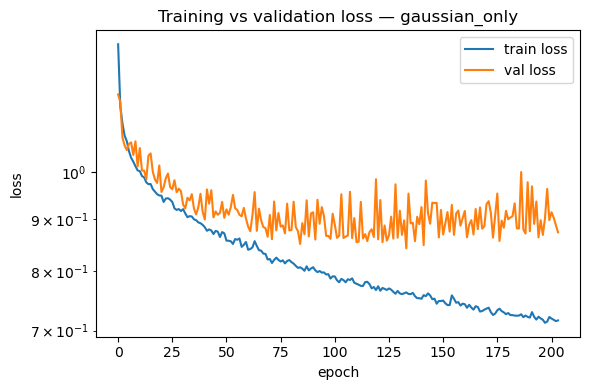

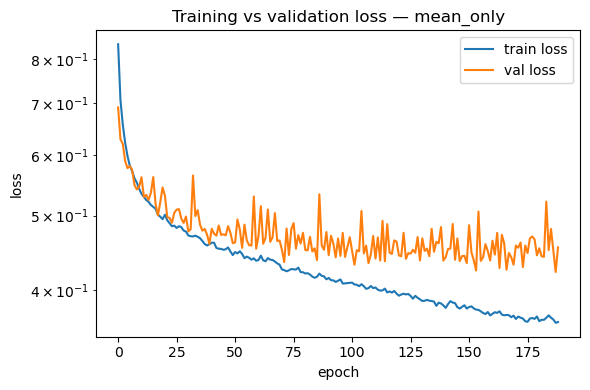

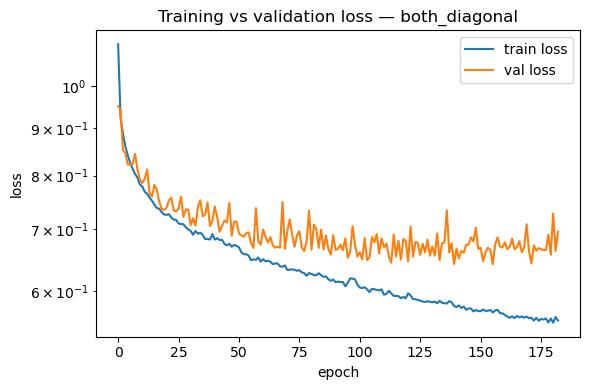

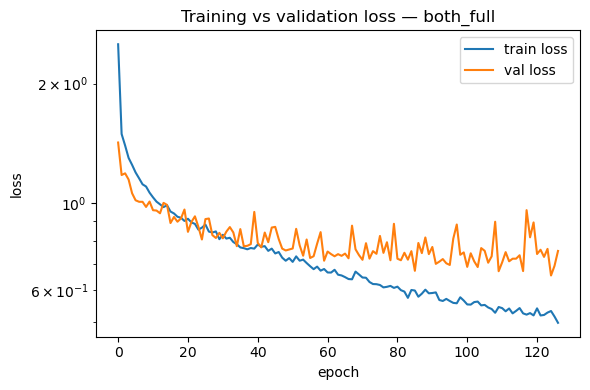

In [12]:
for mode_name, history in histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(history.get("train_loss", []), label="train loss")
    plt.plot(history.get("val_loss", []), label="val loss")
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Training vs validation loss — {mode_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Predict on validation set and compute MSEs

For each curvature, compare:

- marker-conditional baseline
- curvature-only model
- both-target diagonal model
- both-target full-covariance model

In [13]:
from src.inference.predict import predict_targets
from src.analysis.marker_stats import compute_markerwise_residuals

all_predictions = {}
summary_rows = []
markerwise_results = {}

device = next(iter(mode_data.values()))["cfg"].device

for mode_name, model in models.items():
    d = mode_data[mode_name]
    mode_cfg = MODE_CONFIGS[mode_name]
    y_true_all, y_pred_all, log_var_all, X_val = predict_targets(
        d["g_val"],
        model,
        device=device,
        return_log_var=True,
        rescale=True,
        center=d["center"],
        scale=d["scale"],
    )
    all_predictions[mode_name] = {
        "y_true_all": y_true_all,
        "y_pred_all": y_pred_all,
        "log_var_all": log_var_all,
        "X": X_val,
    }

    for original_target_index in mode_cfg["target_indices"]:
        local_idx = target_index_within_mode(mode_name, original_target_index)
        y_t, yp_t, lv_t = prepare_scalar_prediction_arrays(
            y_true_all,
            y_pred_all,
            log_var_all,
            target_index=local_idx,
        )

        residuals_model, residuals_base, n_pos, mu_pos = compute_markerwise_residuals(y_t, yp_t, X_val)
        mse_model_marker = np.array([np.mean(r ** 2) if r.size > 0 else np.nan for r in residuals_model])
        mse_base_marker = np.array([np.mean(r ** 2) if r.size > 0 else np.nan for r in residuals_base])
        sem_model_marker = np.array([safe_sem(r ** 2) for r in residuals_model])
        sem_base_marker = np.array([safe_sem(r ** 2) for r in residuals_base])

        markerwise_results[(mode_name, original_target_index)] = {
            "mse_model": mse_model_marker,
            "mse_base": mse_base_marker,
            "sem_model": sem_model_marker,
            "sem_base": sem_base_marker,
            "n_pos": n_pos,
        }

        summary_rows.append({
            "target_index": original_target_index,
            "target_label": TARGET_LABELS_ALL[original_target_index],
            "mode": mode_name,
            "display": MODE_DISPLAY_NAMES[mode_name],
            "mse": finite_mse(y_t, yp_t),
            "mae": finite_mae(y_t, yp_t),
            "baseline_mse": float(np.nanmean(mse_base_marker)),
            "mean_marker_mse": float(np.nanmean(mse_model_marker)),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,target_index,target_label,mode,display,mse,mae,baseline_mse,mean_marker_mse
0,0,Gaussian curvature,gaussian_only,curvature only,0.003519,0.038941,0.005225,0.003861
1,1,Mean curvature,mean_only,curvature only,0.006250,0.058674,0.009789,0.006990
2,0,Gaussian curvature,both_diagonal,"both, diagonal",0.003592,0.039087,0.005225,0.004030
3,1,Mean curvature,both_diagonal,"both, diagonal",0.006388,0.059284,0.009789,0.007399
4,0,Gaussian curvature,both_full,"both, covariant",0.003764,0.040171,0.005225,0.004220
5,1,Mean curvature,both_full,"both, covariant",0.006678,0.060462,0.009789,0.007701


## Aggregate MSE comparison by curvature

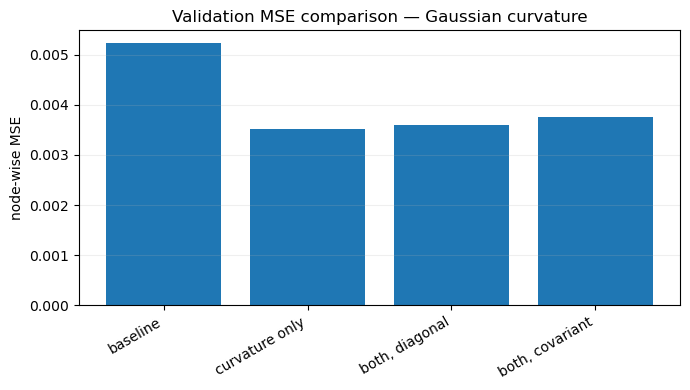

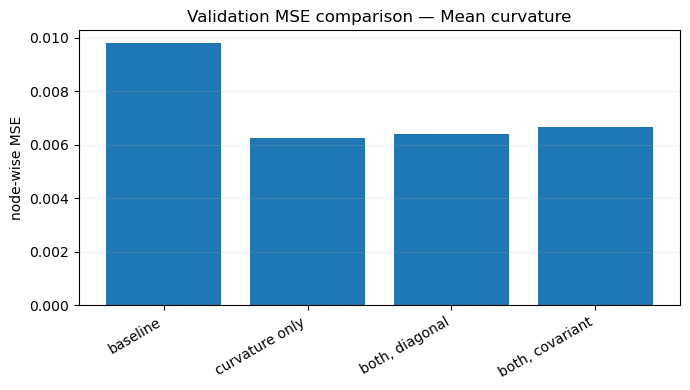

In [14]:
for target_index, modes in COMPARISON_BY_CURVATURE.items():
    target_label = TARGET_LABELS_ALL[target_index]

    names = []
    vals = []

    # Baseline: use baseline from the curvature-only model if available, otherwise first mode containing target.
    baseline_source = "gaussian_only" if target_index == 0 else "mean_only"
    if (baseline_source, target_index) not in markerwise_results:
        baseline_source = next(m for m in MODE_CONFIGS if target_index in MODE_CONFIGS[m]["target_indices"])
    base_val = summary_df.loc[
        (summary_df["target_index"] == target_index) & (summary_df["mode"] == baseline_source),
        "baseline_mse",
    ].iloc[0]

    for mode in modes:
        if mode == "baseline":
            names.append("baseline")
            vals.append(base_val)
        else:
            row = summary_df[(summary_df["target_index"] == target_index) & (summary_df["mode"] == mode)]
            if len(row) == 0:
                continue
            names.append(MODE_DISPLAY_NAMES[mode])
            vals.append(float(row["mse"].iloc[0]))

    plt.figure(figsize=(7, 4))
    x = np.arange(len(names))
    plt.bar(x, vals)
    plt.xticks(x, names, rotation=30, ha="right")
    plt.ylabel("node-wise MSE")
    plt.title(f"Validation MSE comparison — {target_label}")
    plt.grid(True, axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

## Per-marker MSE comparison by curvature

This compares baseline, curvature-only, both diagonal, and both full covariance marker-wise.

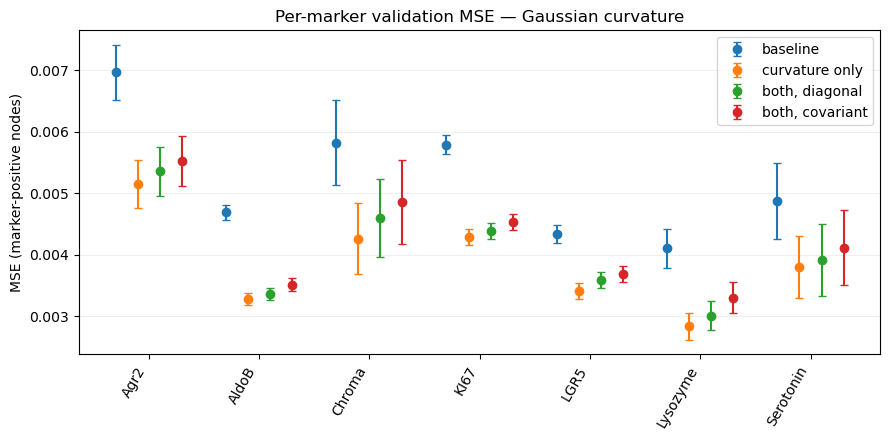

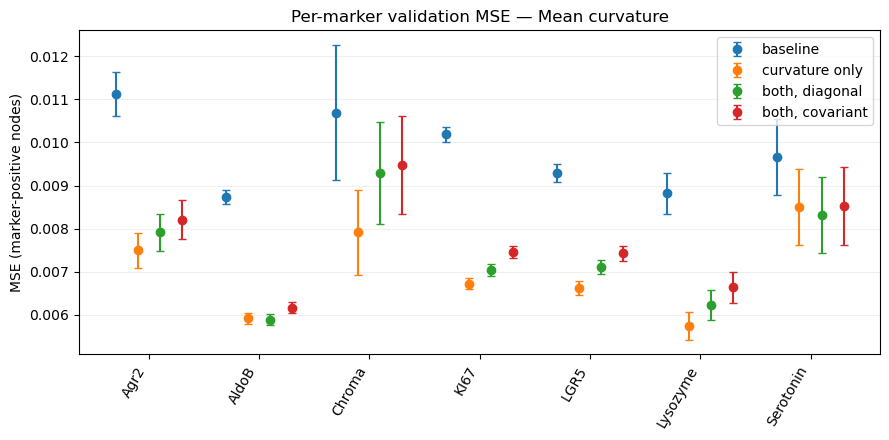

In [15]:
for target_index, modes in COMPARISON_BY_CURVATURE.items():
    target_label = TARGET_LABELS_ALL[target_index]

    plt.figure(figsize=(max(9, 0.65 * len(marker_names)), 4.5))
    x = np.arange(len(marker_names), dtype=float)

    plot_modes = [m for m in modes if m == "baseline" or (m, target_index) in markerwise_results]
    width = 0.8 / len(plot_modes)
    offsets = (np.arange(len(plot_modes)) - (len(plot_modes) - 1) / 2.0) * width

    baseline_source = "gaussian_only" if target_index == 0 else "mean_only"
    if (baseline_source, target_index) not in markerwise_results:
        baseline_source = next(m for m in MODE_CONFIGS if target_index in MODE_CONFIGS[m]["target_indices"])

    for offset, mode in zip(offsets, plot_modes):
        if mode == "baseline":
            r = markerwise_results[(baseline_source, target_index)]
            y = r["mse_base"]
            yerr = r["sem_base"]
            label = "baseline"
        else:
            r = markerwise_results[(mode, target_index)]
            y = r["mse_model"]
            yerr = r["sem_model"]
            label = MODE_DISPLAY_NAMES[mode]

        plt.errorbar(x + offset, y, yerr=yerr, fmt="o", capsize=3, label=label)

    plt.xticks(x, marker_names, rotation=60, ha="right")
    plt.ylabel("MSE (marker-positive nodes)")
    plt.title(f"Per-marker validation MSE — {target_label}")
    plt.grid(True, axis="y", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Four-panel forced-organoid mesh comparison

For each forced validation organoid and each curvature, this produces a 4-panel Plotly figure:

1. ground truth
2. prediction from curvature-only model
3. prediction from both-target diagonal model
4. prediction from both-target full-covariance model

In [17]:
from plotly.subplots import make_subplots
from src.data.splits import select_graphs_by_keys, graph_metadata_key
from src.plotting.mesh_plots import project_predictions_to_mesh
from organograph.plotting.meshes import plot_organoid_mesh


def extract_raw_target_from_graphs(graphs, target_index):
    """Extract one unscaled target from graphs with y shape (N,) or (N, D)."""
    ys = []
    for g in graphs:
        y = g.y.detach().cpu().numpy()
        if y.ndim == 1:
            if target_index != 0:
                raise ValueError("Cannot extract target_index > 0 from 1D g.y")
            ys.append(y.reshape(-1))
        else:
            ys.append(y[:, target_index].reshape(-1))
    return np.concatenate(ys, axis=0)


def _plot_mesh_values(
    mesh,
    values,
    *,
    vmin,
    vmax,
    colorscale="RdBu_r",
    center_at_zero=True,
    show_colorbar=False,
    fig_size=(450, 450),
    view=None,
):
    return plot_organoid_mesh(
        mesh,
        vertex_values=np.asarray(values, dtype=float),
        backend="plotly",
        colorscale=colorscale,
        center_at_zero=center_at_zero,
        vmin=vmin,
        vmax=vmax,
        show_colorbar=show_colorbar,
        fig_size=fig_size,
        view=view,
    )


def plot_four_panel_curvature_mesh(
    result_truth,
    pred_mesh_values,
    *,
    titles,
    title,
    colorscale="RdBu_r",
    center_at_zero=True,
    fig_size=(1800, 500),
    view=None,
):
    mesh = result_truth["mesh"]

    vals_all = [
        np.asarray(result_truth["mesh_true"], dtype=float),
        *[np.asarray(v, dtype=float) for v in pred_mesh_values],
    ]

    finite_vals = np.concatenate([v.ravel() for v in vals_all])
    finite_vals = finite_vals[np.isfinite(finite_vals)]

    if finite_vals.size == 0:
        vmin, vmax = -1.0, 1.0
    elif center_at_zero:
        m = float(np.max(np.abs(finite_vals)))
        m = 1.0 if m == 0.0 else m
        vmin, vmax = -m, m
    else:
        vmin, vmax = float(np.min(finite_vals)), float(np.max(finite_vals))
        if vmin == vmax:
            vmin -= 1.0
            vmax += 1.0

    figs = []
    for i, vals in enumerate(vals_all):
        figs.append(
            _plot_mesh_values(
                mesh,
                vals,
                vmin=vmin,
                vmax=vmax,
                colorscale=colorscale,
                center_at_zero=center_at_zero,
                show_colorbar=(i == 0),
                fig_size=(450, 450),
                view=view,
            )
        )

    fig = make_subplots(
        rows=1,
        cols=4,
        specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
        subplot_titles=titles,
        horizontal_spacing=0.02,
    )

    for col, f in enumerate(figs, start=1):
        for tr in f.data:
            fig.add_trace(tr, row=1, col=col)

        scene_src = f.layout.scene.to_plotly_json() if f.layout.scene else {}
        scene_name = "scene" if col == 1 else f"scene{col}"
        fig.layout[scene_name].update(scene_src)

    fig.update_layout(
        width=int(fig_size[0]),
        height=int(fig_size[1]),
        title=title,
    )
    return fig


# -------------------------------------------------------------------------
# Select forced validation organoids from ORIGINAL two-target validation set
# -------------------------------------------------------------------------
g_val_selected = select_graphs_by_keys(
    base_val_all,
    split_info["forced_val_keys"],
    key_fn=graph_metadata_key,
    meta_lookup=val_meta_lookup,
)

selected_meta_lookup = {
    getattr(g, "organoid_str"): val_meta_lookup[getattr(g, "organoid_str")]
    for g in g_val_selected
}

sizes_selected = [int(g.y.shape[0]) for g in g_val_selected]


# -------------------------------------------------------------------------
# Predictions on selected graphs for each mode
# -------------------------------------------------------------------------
selected_predictions = {}

for mode_name, model_m in models.items():
    d = mode_data[mode_name]

    g_selected_mode = select_graph_targets(
        g_val_selected,
        MODE_CONFIGS[mode_name]["target_indices"],
        inplace=False,
    )

    y_true_all_m, y_pred_all_m, log_var_all_m, X_selected = predict_targets(
        g_selected_mode,
        model_m,
        device=device,
        return_log_var=True,
        rescale=True,
        center=d["center"],
        scale=d["scale"],
    )

    selected_predictions[mode_name] = {
        "graphs": g_selected_mode,
        "y_true_all": y_true_all_m,
        "y_pred_all": y_pred_all_m,
        "log_var_all": log_var_all_m,
    }


# -------------------------------------------------------------------------
# Diagnostics: check raw truth scale vs rescaled prediction scale
# -------------------------------------------------------------------------
for target_index in [0, 1]:
    target_label = TARGET_LABELS_ALL[target_index]
    y_true_raw = extract_raw_target_from_graphs(g_val_selected, target_index)

    print(f"\n=== {target_label} ===")
    print(
        "truth raw:",
        "min=", np.nanmin(y_true_raw),
        "max=", np.nanmax(y_true_raw),
        "mean=", np.nanmean(y_true_raw),
        "std=", np.nanstd(y_true_raw),
    )

    for mode_name in ["gaussian_only", "mean_only", "both_diagonal", "both_full"]:
        if mode_name not in selected_predictions:
            continue
        if target_index not in MODE_CONFIGS[mode_name]["target_indices"]:
            continue

        local_idx = target_index_within_mode(mode_name, target_index)

        _, yp_m, _ = prepare_scalar_prediction_arrays(
            selected_predictions[mode_name]["y_true_all"],
            selected_predictions[mode_name]["y_pred_all"],
            selected_predictions[mode_name]["log_var_all"],
            target_index=local_idx,
        )

        print(
            mode_name,
            "pred:",
            "min=", np.nanmin(yp_m),
            "max=", np.nanmax(yp_m),
            "mean=", np.nanmean(yp_m),
            "std=", np.nanstd(yp_m),
        )


# -------------------------------------------------------------------------
# Four-panel mesh plots:
# one figure per curvature per selected organoid
# -------------------------------------------------------------------------
for target_index in [0, 1]:
    target_label = TARGET_LABELS_ALL[target_index]

    only_mode = "gaussian_only" if target_index == 0 else "mean_only"
    pred_modes = [only_mode, "both_diagonal", "both_full"]

    panel_titles = [
        "Ground truth",
        "Prediction (curvature only)",
        "Prediction (both, diagonal)",
        "Prediction (both, covariant)",
    ]

    # Use raw, unscaled original validation targets for truth.
    y_true_raw = extract_raw_target_from_graphs(g_val_selected, target_index)

    # Extract selected-target predictions from each trained mode.
    scalar_preds = {}
    for mode_name in pred_modes:
        local_idx = target_index_within_mode(mode_name, target_index)

        _, y_pred_m, _ = prepare_scalar_prediction_arrays(
            selected_predictions[mode_name]["y_true_all"],
            selected_predictions[mode_name]["y_pred_all"],
            selected_predictions[mode_name]["log_var_all"],
            target_index=local_idx,
        )

        scalar_preds[mode_name] = y_pred_m

    for graph_index, g in enumerate(g_val_selected):
        s = int(np.sum(sizes_selected[:graph_index]))
        e = s + sizes_selected[graph_index]

        truth_result = project_predictions_to_mesh(
            graph_index,
            g_val_selected,
            y_true_raw,
            y_true_raw,
            meta_lookup=selected_meta_lookup,
        )

        pred_mesh_values = []
        metrics = []

        for mode_name in pred_modes:
            pred_result = project_predictions_to_mesh(
                graph_index,
                g_val_selected,
                y_true_raw,
                scalar_preds[mode_name],
                meta_lookup=selected_meta_lookup,
            )

            pred_mesh_values.append(pred_result["mesh_pred"])

            mae_i = finite_mae(y_true_raw[s:e], scalar_preds[mode_name][s:e])
            mse_i = finite_mse(y_true_raw[s:e], scalar_preds[mode_name][s:e])
            metrics.append((mode_name, mae_i, mse_i))

        metric_text = " | ".join(
            [
                f"{MODE_DISPLAY_NAMES[m]} MSE={mse:.4f}"
                for m, mae, mse in metrics
            ]
        )

        fig = plot_four_panel_curvature_mesh(
            truth_result,
            pred_mesh_values,
            titles=panel_titles,
            title=f"FORCED | {target_label} | {truth_result['organoid_str']}<br>{metric_text}",
            center_at_zero=True,
        )

        fig.show()


=== Gaussian curvature ===
truth raw: min= -0.37959078 max= 0.27706233 mean= -0.0034990986 std= 0.10224035
gaussian_only pred: min= -0.27114339590463565 max= 0.12919457427976067 mean= -0.09368749836670033 std= 0.07365429525914642
both_diagonal pred: min= -0.25367189827795045 max= 0.08747517753003953 mean= -0.0860168835247993 std= 0.060539544206805934
both_full pred: min= -0.1820485233228819 max= 0.05508619757683075 mean= -0.0619252554595805 std= 0.041265016131773115

=== Mean curvature ===
truth raw: min= -0.22206749 max= 0.49863768 mean= 0.17136884 std= 0.12188488
mean_only pred: min= -0.17457013423131684 max= 0.3964753780505035 mean= 0.0900982550480745 std= 0.11924084505342387
both_diagonal pred: min= -0.17430120485965617 max= 0.31539751074465805 mean= 0.05604604337673999 std= 0.09292342967745025
both_full pred: min= -0.09293501241462465 max= 0.24558105034737077 mean= 0.06404625633511639 std= 0.06447158537456064
